In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, LeaveOneOut
from sklearn.dummy import DummyClassifier

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import optuna
import shap

In [ ]:
df = pd.read_csv('weatherAUS.csv')

In [ ]:
df.info()

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.head()

# Dividir datos de entrenamiento y testeo

In [ ]:
x = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
df.shape

# Tratamiento de nulos

In [ ]:
# Nulos por columna
X_train.isna().sum()

In [ ]:
# Porcentaje de nulos por columna
porcentajes_nulos = (X_train.isna().sum() / len(df)) * 100

print(porcentajes_nulos)

Se observa gran cantidad de nulos en Evaporation, Sunshine, Cloud9am, Cloud3pm

In [ ]:
nan_por_fila = X_train.isna().sum(axis=1)

# Filtramos filas con más de tres NaN
filas_con_mas_de_un_nan = (nan_por_fila > 10).sum()

print(f"Número de filas en X_train con más de 10 NaN en las columnas: {filas_con_mas_de_un_nan}")

# Calculamos porcentaje de filas con más de 10 NaN
porcentaje_filas_con_mas_de_un_nan = (filas_con_mas_de_un_nan / len(X_train)) * 100
print(f"Porcentaje de filas en X_train con más de 10 NaN en las columnas: {porcentaje_filas_con_mas_de_un_nan:.2f}%")


Verificamos las filas que tienen mas del 50% de faltantes

In [ ]:
X_train.shape, y_train.shape

In [ ]:
# eliminar valores con porcentaje de filas con mas de 10 Nan
X_train = X_train[nan_por_fila <= 10]
y_train = y_train[X_train.index]
X_train.shape, y_train.shape

Eliminamos las filas con 10 o mas nulos

Se eliminaron aproximadamente 2000 filas

## Tratamiento valores imposibles

In [ ]:
print(sum(X_train['Evaporation'] > 100))
print(sum(X_train['MinTemp'] < -20))
print(sum(X_train['MaxTemp'] > 70))
print(sum((X_train['Humidity3pm'] < 0) | (X_train['Humidity3pm'] > 100)))
print(sum((X_train['Humidity9am'] < 0) | (X_train['Humidity9am'] > 100)))

In [ ]:
# BORRAMOS DATOS IMPOSIBLES DE "EVAPORATION"
indices_a_mantener = X_train.index[~(X_train['Evaporation'] > 100)]

X_train = X_train.loc[indices_a_mantener]

y_train = y_train.loc[indices_a_mantener]

print(f"Nueva forma de X_train: {X_train.shape}")
print(f"Nueva forma de y_train: {y_train.shape}")

## Nulos en Y_train

In [ ]:
y_train.isna().sum()

Observamos 2607 nulos en la variable objetivo

In [ ]:
y_train.dropna(inplace=True)
# Eliminamos en X_train las filas correspondientes a y_train que fueron eliminadas
X_train = X_train.loc[y_train.index]
# En y_test
y_test.dropna(inplace=True)
X_test = X_test.loc[y_test.index]

Eliminamos los valores nulos de la variable objetivo

# Consigna 1 - Creacion de variable regiones

Decidimos importar un dataset con los datos de las ciudades y provincias de Australia para poder mapear y obtener las provincias.

In [ ]:
X_train["Location"].unique()

Verificamos las ciudades de nuestro dataset

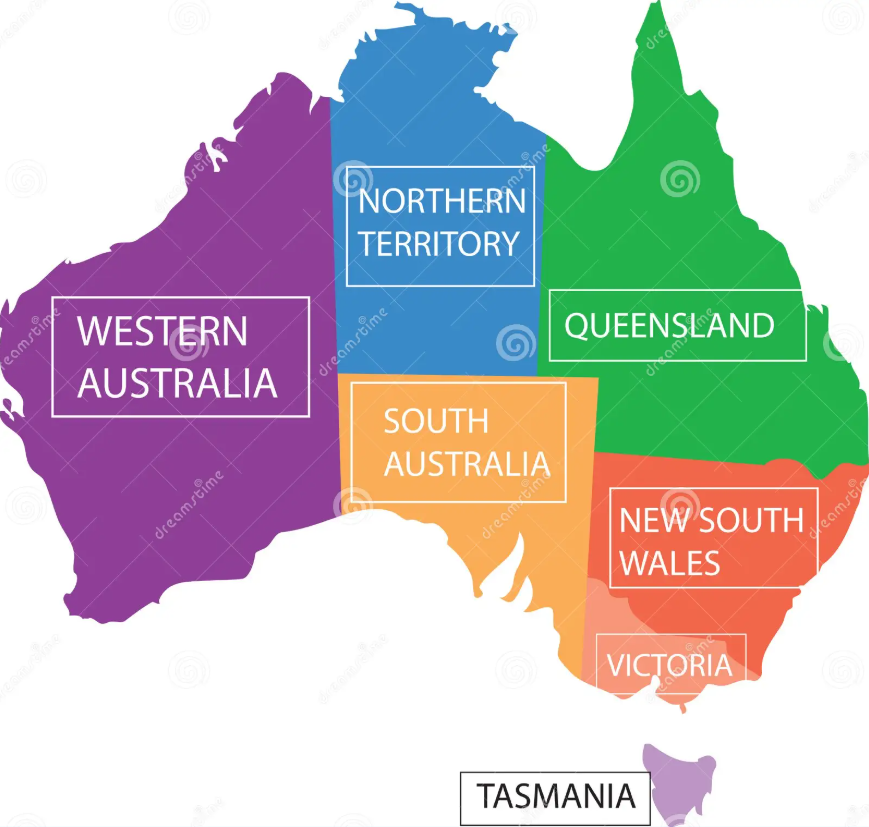

Vemos como es la distribucion de las provincias en el pais para poder agrupar

###  Agrupando por provincia

In [ ]:
# https://www.kaggle.com/datasets/maryamalizadeh/worldcities-australia?resource=download
df_aus = pd.read_csv('au.csv')

In [ ]:
df_aus.shape

In [ ]:
df_aus.head()

In [ ]:
# Diccionario para normalizar nombres de ubicaciones
normalizar_ubicaciones = {
    'MelbourneAirport': 'Melbourne',
    'SydneyAirport': 'Sydney',
    'PerthAirport': 'Perth',
    'PearceRAAF': 'Perth',
    'WaggaWagga': 'Wagga Wagga',        # Corregir formato
    'CoffsHarbour': 'Coffs Harbour',    # Corregir formato
    'MountGambier': 'Mount Gambier',    # Corregir formato
    'Tuggeranong': 'Canberra',          # Suburbio de Canberra
    'BadgerysCreek': 'Sydney',          # Suburbio de Sydney
    'NorahHead': 'Newcastle',           # Cerca de Newcastle
    'Penrith': 'Sydney',                # Suburbio de Sydney
    'Richmond': 'Sydney',               # Suburbio de Sydney
    'GoldCoast': 'Gold Coast',          # Corregir formato
    'NorfolkIsland': 'Norfolk Island',  # Isla externa
    'MountGinini': 'Canberra',          # Cerca de Canberra
    'Nhile': 'Nhill',                   # Corregir error tipográfico
    'Watsonia': 'Melbourne',            # Suburbio de Melbourne
    'Williamtown' : 'Williamstown',     # error tipografico
}

# Aplicamos normalización a la columna Location
X_train['Location_normalized'] = X_train['Location'].replace(normalizar_ubicaciones)

# Creamos diccionario de mapeo de ciudades a provincias desde df_aus
mapeo_ciudades = dict(zip(df_aus['city'], df_aus['admin_name']))

# Mapeamos admin_name usando la columna normalizada
X_train['provincia'] = X_train['Location_normalized'].map(mapeo_ciudades)
# X_test
X_test["Location_normalized"] = X_test['Location'].replace(normalizar_ubicaciones)
X_test["provincia"] = X_test['Location_normalized'].map(mapeo_ciudades)

# Eliminamos la columna temporal Location_normalized
X_train = X_train.drop(columns=['Location_normalized'])
X_test = X_test.drop(columns=['Location_normalized'])

In [ ]:
print(X_train['provincia'].isna().sum())

In [ ]:
X_train.loc[X_train['Location'] == 'NorfolkIsland', 'provincia'] = 'Norfolk Island Territory'

X_train.loc[X_train['Location'] == 'Nhil', 'provincia'] = 'Victoria'
X_train.loc[X_train['Location'] == 'Dartmoor', 'provincia'] = 'Victoria'
X_train.loc[X_train['Location'] == 'Woomera', 'provincia'] = 'South Australia'
X_train.loc[X_train['Location'] == 'Witchcliffe', 'provincia'] = 'Western Australia'
X_train.loc[X_train['Location'] == 'SalmonGums', 'provincia'] = 'Western Australia'
X_train.loc[X_train['Location'] == 'Walpole', 'provincia'] = 'Western Australia'
X_train.loc[X_train['Location'] == 'AliceSprings', 'provincia'] = 'Northern Territory'
X_train.loc[X_train['Location'] == 'Uluru', 'provincia'] = 'Northern Territory'

# X_test
X_test.loc[X_test['Location'] == 'NorfolkIsland', 'provincia'] = 'Norfolk Island Territory'
X_test.loc[X_test['Location'] == 'Nhil', 'provincia'] = 'Victoria'
X_test.loc[X_test['Location'] == 'Dartmoor', 'provincia'] = 'Victoria'
X_test.loc[X_test['Location'] == 'Woomera', 'provincia'] = 'South Australia'
X_test.loc[X_test['Location'] == 'Witchcliffe', 'provincia'] = 'Western Australia'
X_test.loc[X_test['Location'] == 'SalmonGums', 'provincia'] = 'Western Australia'
X_test.loc[X_test['Location'] == 'Walpole', 'provincia'] = 'Western Australia'
X_test.loc[X_test['Location'] == 'AliceSprings', 'provincia'] = 'Northern Territory'
X_test.loc[X_test['Location'] == 'Uluru', 'provincia'] = 'Northern Territory'

In [ ]:
print(X_train['provincia'].isna().sum())

In [ ]:
# Listamos Location y admin_name, eliminando duplicados
lista_ubicaciones = X_train[['Location', 'provincia']].drop_duplicates()

print(lista_ubicaciones)

### Intentar obtener latitud y longitud

In [ ]:
# Aplicamos normalización a la columna Location
X_train['Location_normalized'] = X_train['Location'].replace(normalizar_ubicaciones)
# Diccionarios de mapeo
mapeo_lat = dict(zip(df_aus['city'], df_aus['lat']))
mapeo_lon = dict(zip(df_aus['city'], df_aus['lng']))
# Usamos Location_normalized para encontrar las coordenadas
X_train['lat'] = X_train['Location_normalized'].map(mapeo_lat)
X_train['lon'] = X_train['Location_normalized'].map(mapeo_lon)

# Repetimos el proceso para X_test_imputado
X_test['Location_normalized'] = X_test['Location'].replace(normalizar_ubicaciones)
X_test['lat'] = X_test['Location_normalized'].map(mapeo_lat)
X_test['lon'] = X_test['Location_normalized'].map(mapeo_lon)



# Eliminamos la columna temporal Location_normalized
X_train = X_train.drop(columns=['Location_normalized'])
X_test = X_test.drop(columns=['Location_normalized'])

In [ ]:
X_train[['lat', 'lon']].isna().sum()

In [ ]:
X_train.loc[X_train['Location'] == 'NorfolkIsland', ['lat', 'lon']] = [-29.0333, 167.9497]

In [ ]:
# Listamos Location, latitudes y longitudes eliminando duplicados
lista_ubicaciones = X_train[['Location', 'lat','lon']].drop_duplicates()

print(lista_ubicaciones)

In [ ]:
coordenadas_correccion = {
    'Nhil': [-36.3333, 141.6500],          # Nhill, Victoria
    'Dartmoor': [-37.9221, 141.2767],      # Dartmoor, Victoria
    'Woomera': [-31.2010, 136.8329],       # Woomera, South Australia
    'Witchcliffe': [-34.0251, 115.1004],   # Witchcliffe, Western Australia
    'SalmonGums': [-32.9816, 121.6439],    # Salmon Gums, Western Australia
    'AliceSprings': [-23.6980, 133.8807],  # Alice Springs, Northern Territory
    'Uluru': [-25.3444, 131.0369],         # Uluru, Northern Territory
    'PearceRAAF': [-31.6678, 116.0150],    # Pearce RAAF, Western Australia
    'PerthAirport': [-31.9403, 115.9669],  # Perth Airport, Western Australia
    'Perth': [-31.9559, 115.8606]          # Perth, Western Australia
}

# Actualizamos las columnas lat y lon
for location, (lat, lon) in coordenadas_correccion.items():
    X_train.loc[X_train['Location'] == location, ['lat', 'lon']] = [lat, lon]
# X_test_imputado
for location, (lat, lon) in coordenadas_correccion.items():
    X_test.loc[X_test['Location'] == location, ['lat', 'lon']] = [lat, lon]


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_train, x='lon', y='lat', hue='provincia', alpha=0.5)
plt.title('Distribución geográfica de las ubicaciones')

In [ ]:
# Creamos la figura con proyección cartográfica
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Añadimos el mapa de fondo de Australia con Continentes, Océanos, Líneas costeras, Fronteras y Provincias
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='black')

# Establecemos el límite del mapa para centrarse en Australia
ax.set_extent([110, 170, -45, -10], crs=ccrs.PlateCarree())

# Scatter plot
sns.scatterplot(data=X_train, x='lon', y='lat', hue='provincia', alpha=1, ax=ax, transform=ccrs.PlateCarree())
plt.title('Distribución geográfica de las ubicaciones en Australia')
plt.legend(title='Provincia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Imputacion por provincia

In [ ]:
X_train_imputado = X_train.copy()
X_test_imputado = X_test.copy()

cols_numericas = X_train.select_dtypes(include='number').columns
cols_categoricas = X_train.select_dtypes(exclude='number').columns.drop('provincia', errors='ignore')

# Imputamos las numericas con la media

# Calculamos las medias de X_train agrupadas por provincia
medias_por_prov = X_train.groupby('provincia')[cols_numericas].mean()

# X_train
fill_values_train_num = X_train.groupby('provincia')[cols_numericas].transform('mean')
X_train_imputado = X_train_imputado.fillna(fill_values_train_num)

# X_test:
for col in cols_numericas:
    fill_values_test_num = X_test_imputado['provincia'].map(medias_por_prov[col])
    X_test_imputado[col] = X_test_imputado[col].fillna(fill_values_test_num)

# Imputamos categoricas

# Calculamos las modas de X_train agrupadas por provincia
calc_moda = lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA
modas_por_prov = X_train.groupby('provincia')[cols_categoricas].agg(calc_moda)

# X_train
fill_values_train_cat = X_train.groupby('provincia')[cols_categoricas].transform(calc_moda)
X_train_imputado = X_train_imputado.fillna(fill_values_train_cat)

# X_test
for col in cols_categoricas:
    fill_values_test_cat = X_test_imputado['provincia'].map(modas_por_prov[col])
    X_test_imputado[col] = X_test_imputado[col].fillna(fill_values_test_cat)

In [ ]:
print(X_train_imputado.isna().sum())
print(X_test_imputado.isna().sum())

In [ ]:
# Graficos comparativos antes y después de la imputación

cols_a_escalar = [
    'MinTemp',
    'MaxTemp',
    'Rainfall',
    'Evaporation',
    'Sunshine',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm',
    'Humidity9am',
    'Humidity3pm',
    'Pressure9am',
    'Pressure3pm',
    'Cloud9am',
    'Cloud3pm',
    'Temp9am',
    'Temp3pm'
]

fig, axes = plt.subplots(nrows=len(cols_a_escalar), ncols=2, figsize=(12, 30), sharey='row')

for i, col in enumerate(cols_a_escalar):
    data_antes = X_train[col].dropna()
    sns.kdeplot(data=data_antes,  color='red', alpha=0.4, ax=axes[i][0])
    axes[i][0].set_title(f'{col} (Antes de imputación)')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frecuencia')

    # Después de la imputación
    data_despues = X_train_imputado[col]
    sns.kdeplot(data=data_despues,  color='blue', alpha=0.4, ax=axes[i][1])
    axes[i][1].set_title(f'{col} (Después de imputación)')
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

A simple vista se puede notar que las variables que sufrieron un cambio considerable en su distribución:
- `Evaporation`: El pico que presenta en el grafico se vuelve mucho mas pronunciado luego de la imputación.
- `Sunshine`: Se vuelve mucho más frecuente en el rango de [6.5, 8.5].
- `WindGustSpeed`: Se genera un pico en torno a los 40 km/h.
- `Pressure9am`: Se genera un pico en torno a los 1018 hectopascales.
- `Pressure3pm`: Lo mismo, pero cerca de los 1015 hectopascales.
- `Cloud9am` y `Cloud3pm`: Se genera un pico entre las 4 y 5.5 oktas (medición que describe la nubosidad)

# Graficos

In [ ]:
X_train_imputado["Date"] = pd.to_datetime(X_train_imputado["Date"], format="%Y-%m-%d")
X_train_imputado["year"] = X_train_imputado["Date"].dt.year
X_train_imputado["month"] = X_train_imputado["Date"].dt.month
X_train_imputado["day"] = X_train_imputado["Date"].dt.day
X_test_imputado["Date"] = pd.to_datetime(X_test_imputado["Date"], format="%Y-%m-%d")
X_test_imputado["year"] = X_test_imputado["Date"].dt.year
X_test_imputado["month"] = X_test_imputado["Date"].dt.month
X_test_imputado["day"] = X_test_imputado["Date"].dt.day

In [ ]:
location_counts = X_train_imputado['provincia'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.index, y=location_counts.values)
plt.title('Cantidad de datos por provincia')
plt.xticks(rotation=90)
plt.show()

La mayor cantidad de registros provienen de la parte perteneciente al sudeste de Australia (`New South Wales` y `Victoria`).

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=X_train_imputado, x="MinTemp", color="blue", label="MinTemp", kde=True, alpha=0.6)
sns.histplot(data=X_train_imputado, x="MaxTemp", color="red", label="MaxTemp", kde=True, alpha=0.6)
plt.legend()
plt.title("Distribución de temperaturas mínimas y máximas")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")
plt.show()

Vemos que las distribuciones de las temperaturas maximas y minimas presentan una distribucion normal. Como se esperaba, la distribucion de las temperaturas maximas se encuentran significativamente mas a la derecha que la distribucion de las temperaturas minimas.

In [ ]:
X_train_imputado.describe()

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=X_train_imputado, x="MinTemp", color="blue", label="MinTemp")
sns.boxplot(data=X_train_imputado, x="MaxTemp", color="red", label="MaxTemp")
plt.title("Boxplot de temperaturas mínimas y máximas")
plt.xlabel("Temperatura")
plt.show()

Complementariamente al grafico anterior, vemos que:
- `MinTemp`
  - Tiene bastantes outliers ***"frios"***, y casi no posee outliers ***"calidos"***.
  - El 50% central de los datos se encuentra en el rango de 7.6ºC a 16.8ºC.
  - La mediana se encuentra justo en los 12º con una media de 12.18ºC (muy parecido)
- `MaxTemp`
  - Presenta bastantes outliers, tanto ***"frios"*** como ***"calidos"***.
  - El 50% central de los datos se encuentra entre 17.9ºC y 28.2ºC.
  - Al igual que con `MinTemp`, la mediana y la media son similares, con valores de 22.6ºC y 23.2ºC respectivamente (una diferencia de 0.6ºC)

In [ ]:
# Gráficos de distribución para todas las columnas numéricas

numeric_cols = X_train_imputado.select_dtypes(include=['float64']).columns

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=X_train_imputado, x=col, kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

- Además de `MinTemp` y `MaxTemp`, vemos que `Temp9am` y `Temp3pm` también tienen distribuciones casi normales.
- `Humidity3pm` es bastante normal también, aunque en menor medida que las nombradas anteriormente.
- `Pressure9am` y `Pressure3pm` también son bastante normales con picos.
- `Humidity9am` es un poco diferente con una cola a la izquierda, indicando que las mañanas suelen ser más húmedas.
- Las variables relacionadas al viento (`WindGustSpeed`, `WindSpeed9am` y `WindSpeed3pm`) se concentran en la parte izquierda con colas hacia la derecha, lo que indica que, en su mayoría, son vientos calmos o brisas ligeras.
- `Sunshine`, `Cloud9am`, `Cloud3pm`, `lat` y `lon` son multimodales.
- `Rainfall` y `Evaporation` se encuentran concentrados en los valores más bajos con una cola muy larga hacia la derecha.

In [ ]:
# Gráficos de boxplot para las columnas numéricas

numeric_cols = X_train_imputado.select_dtypes(include=['float64']).columns

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=X_train_imputado, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

In [ ]:
sns.countplot(y_train)
plt.title("Distribución de la variable objetivo (RainTomorrow)")

La variable objetivo esta bastante desbalanceada.

In [ ]:
# Graficamos por año
year_counts = X_train_imputado['year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Cantidad de datos por año')
plt.xlabel('Año')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.show()

## Correlaciones

In [ ]:
# Transformamos y_train a numerica
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [ ]:
# Mapa de correlaciones incluyendo variable objetivo

data_combined = X_train_imputado.copy()
data_combined['target'] = y_train

data_combined_numeric = data_combined.select_dtypes(include=['float64', 'int64', "int32"])  # int32 son los datos de year, mouth y day

corr = data_combined_numeric.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones (incluyendo variable objetivo)")
plt.show()

Observamos que:
- `Humidity3pm` presenta la correlación positiva más fuerte con la variable objetivo (0.44), lo que sugiere que, a mayor humedad a las 3 PM, mayor es la probabilidad de que se produzca el evento objetivo.
- `Cloud9am` y `Cloud3pm` también presentan una correlación positiva con la variable objetivo (aunque no tan alta como `Humidity3pm`) de 0.26 y 0.30 respectivamente.
- `Sunshine` presenta una correlación negativa media de -0.33, lo que indica que, lógicamente, mientras más soleado este menos probabilidad hay de que se produzca el evento objetivo.

# Tratamiento variables categoricas

In [ ]:
# Covertimos variables objeto a categoricas
cols_categoricas = X_train_imputado.select_dtypes(include=['object']).columns
for col in cols_categoricas:
    X_train_imputado[col] = X_train_imputado[col].astype('category')
    X_test_imputado[col] = X_test_imputado[col].astype('category')
X_train_imputado.info()

In [ ]:
# Convertimos Date a datetime
X_train_imputado["Date"] = pd.to_datetime(X_train_imputado["Date"], format="%Y-%m-%d")
X_test_imputado["Date"] = pd.to_datetime(X_test_imputado["Date"], format="%Y-%m-%d")

In [ ]:
# Aplicamos label Encoding a WindGustDir, WindDir9am, WindDir3pm, rainToday y provincia
columnas_label = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',"provincia","Location"]
label_encoders = {}
for col in columnas_label:
    le = LabelEncoder()
    X_train_imputado[col] = le.fit_transform(X_train_imputado[col])
    X_test_imputado[col] = le.transform(X_test_imputado[col])
    label_encoders[col] = le

# Escalar

In [ ]:
# Creamos otro df con SOLO valores numericos
X_train_escalado = X_train_imputado.select_dtypes(include=['float64', 'int64', "int32"])
X_test_escalado = X_test_imputado.select_dtypes(include=['float64', 'int64', "int32"])

In [ ]:
# Escalamos X_train_escalado y X_test_escalado con standarscaler
scaler = StandardScaler()
X_train_escalado = pd.DataFrame(scaler.fit_transform(X_train_escalado), columns=X_train_escalado.columns, index=X_train_escalado.index)
X_test_escalado = pd.DataFrame(scaler.transform(X_test_escalado), columns=X_test_escalado.columns, index=X_test_escalado.index)

# Regresion Logistica

In [ ]:
model = LogisticRegression(random_state=42)

model.fit(X_train_escalado, y_train)

In [ ]:
y_pred_train = model.predict(X_train_escalado)

# Calculamos métricas en Train

accuracy_logreg_train = accuracy_score(y_train, y_pred_train)
classification_report_logreg_train = classification_report(y_train, y_pred_train)

print("Métricas en Entrenamiento (Train)")
print(f'Exactitud (Train): {accuracy_logreg_train}')
print("Reporte de clasificación (Train):")
print(classification_report_logreg_train)

In [ ]:
y_pred = model.predict(X_test_escalado)

# Calcular métricas en test
accuracy_logreg = accuracy_score(y_test, y_pred)

classification_report_logreg = classification_report(y_test, y_pred)

print("Métricas en test:")
print(f'Exactitud: {accuracy_logreg}')
print("Reporte de clasificación:")
print(classification_report_logreg)

- El modelo es mucho mejor prediciendo días sin lluvia que días con lluvia.
- Solo fue capaz de detectar el 49% de los dias de lluvia a diferencia de los dias sin lluvia, los cuales detecta el 94%.
- Lo mismo pasa con el f1-score.
- Esto puede deberse al desbalance de clases.
- Ya que las metricas en Train y Test son las mismas podemos decir que no existe sobreajuste, generaliza correctamente.

In [ ]:
confusion_matrix_logreg = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Lluvia', 'Lluvia'],
            yticklabels=['No Lluvia', 'Lluvia'])
plt.title('Matriz de confusión - regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Los FN (Falsos Negativos) son 3280. Son los días de lluvia que el modelo no detectó.

Este valor es malo, coincide con el recall visto previamente.

### Logistic Regression con balanceo

In [ ]:
# Probamos con class_weight='balanced' para ver si mejora las metricas
model_weight = LogisticRegression(random_state=42, class_weight='balanced')
model_weight.fit(X_train_escalado, y_train)
y_pred_weight = model_weight.predict(X_test_escalado)
accuracy_logreg_weight = accuracy_score(y_test, y_pred_weight)
classification_report_logreg_weight = classification_report(y_test, y_pred_weight)
print("Métricas en test con class_weight='balanced':")
print(f'Exactitud: {accuracy_logreg_weight}')
print("Reporte de clasificación:")
print(classification_report_logreg_weight)

Dado el class_weight='balanced' la métrica de recall mejora mucho en 1 (lluvia), ahora detecta el 77% de los días en los que realmente llueve, en comparación con el 49% anterior.

In [ ]:
confusion_matrix_logreg = confusion_matrix(y_test, y_pred_weight)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Lluvia', 'Lluvia'],
            yticklabels=['No Lluvia', 'Lluvia'])
plt.title('Matriz de confusión - regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Se puede ver la misma mejora en el grafico de confusión, con casi 5000 datos bien clasificados en lluvia y casi 1500 de forma errónea.

## Curva ROC

In [ ]:
# Obtenemos las probabilidades de predicción del modelo
y_probs = model.predict_proba(X_test_escalado)[:, 1]

# Calculo la ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

La curva se encuentra muy por encima de la diagonal, lo que confirma que las predicciones son significativamente mejores que el azar.

## Cálculo mejor umbral

In [ ]:
# Calculamos el G-Mean para cada umbral
gmeans = np.sqrt(tpr * (1 - fpr))

# Encontramos el índice (ix) del G-Mean más alto
ix = np.argmax(gmeans)

mejor_umbral = thresholds[ix]
print(f'Mejor umbral (basado en G-Mean): {mejor_umbral}')

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# mejor umbral
plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', label=f'Mejor Umbral (G-Mean) = {mejor_umbral:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

y_probs = model.predict_proba(X_test_escalado)[:, 1]

# Calculamos precisión, recall y umbrales para la curva PR
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)

# Calculamos F1-Score para cada umbral
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
# Manejamos divisiones por cero si precision+recall es 0
f1_scores = np.nan_to_num(f1_scores, nan=0.0)

# Encontramos el índice del F1-Score más alto
ix_f1 = np.argmax(f1_scores)

mejor_umbral_f1 = thresholds_pr[ix_f1]
print(f'Mejor umbral (basado en F1-Score): {mejor_umbral_f1}')

## Modelo base

In [ ]:
# Implementamos el Modelo Base
modelo_base = DummyClassifier(strategy='stratified')

modelo_base.fit(X_train_escalado, y_train)

print("RESULTADOS MODELO BASE: ")

# Métricas en Train
y_pred_base_train = modelo_base.predict(X_train_escalado)
accuracy_base_train = accuracy_score(y_train, y_pred_base_train)

report_base_train = classification_report(y_train, y_pred_base_train, zero_division=0)

print("\nMétricas en Entrenamiento (Train) - Modelo Base")
print(f'Exactitud (Train): {accuracy_base_train}')
print("Reporte de clasificación (Train):")
print(report_base_train)

# Métricas en Test
y_pred_base_test = modelo_base.predict(X_test_escalado)
accuracy_base_test = accuracy_score(y_test, y_pred_base_test)

report_base_test = classification_report(y_test, y_pred_base_test, zero_division=0)

print("\nMétricas en Test - Modelo Base")
print(f'Exactitud (Test): {accuracy_base_test}')
print("Reporte de clasificación (Test):")
print(report_base_test)

# Matriz de Confusión (Test)
confusion_matrix_base = confusion_matrix(y_test, y_pred_base_test)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_base, annot=True, fmt='d', cmap='Greys',
            xticklabels=['No Lluvia', 'Lluvia'],
            yticklabels=['No Lluvia', 'Lluvia'])
plt.title('Matriz de confusión - modelo base')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

In [ ]:
# Obtengo las probabilidades de predicción del modelo
y_prob_base = modelo_base.predict_proba(X_test_escalado)[:, 1]

# Calculo la ROC y el AUC
fpr_base, tpr_base, thresholds_base = roc_curve(y_test, y_prob_base)
roc_auc_base = auc(fpr_base, tpr_base)

In [ ]:
# curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_base, tpr_base, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc_base)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# Kfolds

In [ ]:
cv_strategies = [
    ("KFold", KFold(n_splits=5, shuffle=True, random_state=42)),
    ("StratifiedKFold", StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
]
# ("Leave-One-Out", LeaveOneOut()),

results = {}
for name, cv in cv_strategies:
    scores = cross_val_score(model, X_train_escalado, y_train, cv=cv)
    results[name] = scores

In [ ]:
plt.figure(figsize=(10, 6))
for name, scores in results.items():
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=name)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Estrategias de validación cruzada")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results['KFold']

for strategy in cv_strategies:
  print('Media para la estrategia', strategy[0],':',results['KFold'].mean())
  print('Desvío estándar para la estrategia', strategy[0],':',results['KFold'].std())

# Optimizacion

In [ ]:
# random search
random_params  = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],'class_weight': [None, 'balanced'],'penalty': ['l1', 'l2'],'solver': ['liblinear']}


random_search = RandomizedSearchCV(LogisticRegression(random_state=42), random_params, n_iter=4, cv=5, scoring='f1_weighted', n_jobs=-1)
random_search.fit(X_train_escalado, y_train)
best_random_params = random_search.best_params_
best_random_model = LogisticRegression(**best_random_params, random_state=42)
best_random_model.fit(X_train_escalado, y_train)
random_search_f1 = f1_score(y_test, best_random_model.predict(X_test_escalado))

print(f'Mejores parámetros Random Grid{best_random_params}')
print(f'F1: {random_search_f1}')

In [ ]:
# optuna

def objective(trial):
    C = trial.suggest_float('C', 0.0001, 100.0, log=True)
    
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    
    solver = trial.suggest_categorical('solver', ['liblinear']) 
    
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    model = LogisticRegression(C=C, class_weight=class_weight, penalty=penalty, solver=solver, random_state=42)

    score = cross_val_score(
        model, 
        X_train_escalado, 
        y_train, 
        cv=5, 
        scoring='f1', # Optuna maximizará esta métrica por defecto
        n_jobs=-1
    ).mean()
    return score


study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=4) 

best_optuna_params = study.best_params
best_optuna_f1_cv = study.best_value

best_optuna_model = LogisticRegression(**best_optuna_params, random_state=42)
best_optuna_model.fit(X_train_escalado, y_train)

random_search_f1 = f1_score(y_test, best_optuna_model.predict(X_test_escalado))

In [ ]:
print(f'\n Resultados de la optimización con Optuna')
print(f'Mejores parámetros Optuna: {best_optuna_params}')
print(f'F1 promedio (CV) del mejor trial: {best_optuna_f1_cv:.4f}')
print(f'F1 Score final en el conjunto de prueba: {random_search_f1:.4f}')

# Shap

In [ ]:
explainer = shap.Explainer(model, X_train_escalado, feature_names= X_train_escalado.columns.tolist())
shap_values = explainer(X_test_escalado)
shap_values.shape

## Shap local

In [ ]:
index=0
model.predict_proba(X_test_escalado)[index]

In [ ]:
model.predict(X_test_escalado)[index]
shap_values = explainer(X_test_escalado)
print(shap_values.shape)

In [ ]:
feature_names_list = X_test_escalado.columns.tolist()

explanation = shap.Explanation(values=shap_values[index], base_values=explainer.expected_value, data=X_test_escalado.iloc[index].values,feature_names=feature_names_list)

shap.force_plot(explanation, matplotlib=True, figsize=(18, 6),text_rotation=45)

shap.plots.waterfall(explanation)

## Shap global

In [ ]:
#explanation_global = shap.Explanation(values=shap_values, base_values=explainer.expected_value, feature_names=X_test.columns.tolist(), data=X_test)

feature_names_list = X_test_escalado.columns.tolist() 
explanation_global = shap.Explanation(values=shap_values.values,  data=X_test_escalado.values,base_values=explainer.expected_value,feature_names=feature_names_list)

shap.plots.bar(explanation_global)
shap.plots.beeswarm(explanation_global)